<a href="https://colab.research.google.com/github/Nishanta04/Deep-Learning/blob/main/Preceptron_Loss_Function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **AND Logic for 2 inputs (Perceptron Loss Function 2D)**

In [5]:
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([-1,-1,-1,1])
# X = pd.DataFrame(X)

In [ ]:
X.shape

(4, 2)

In [ ]:
y.shape

(4,)

In [ ]:
y

array([-1, -1, -1,  1])

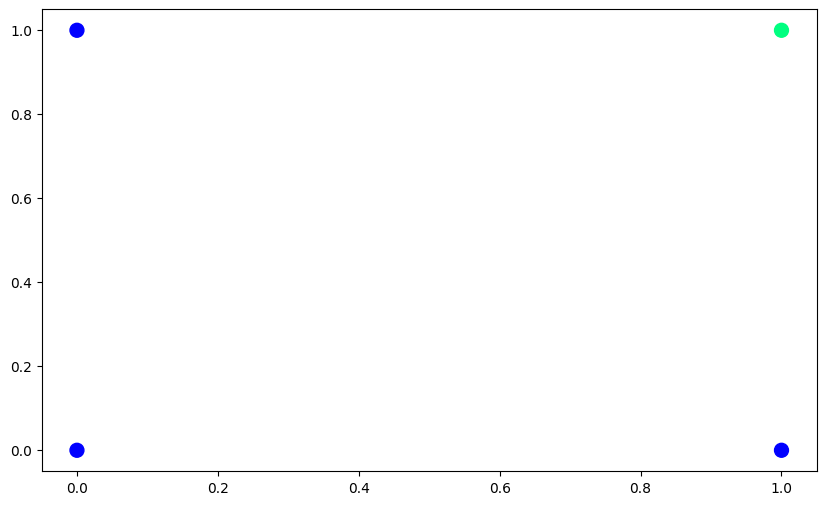

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [7]:
def perceptron(X,y):

    w1=w2=b=1
    lr = 0.1
    count = 0

    for j in range(1000):

        for i in range(X.shape[0]):

            # check condition
            z = w1*X[i][0] + w2*X[i][1] + b

            if z*y[i] < 0:
                count = count + 1
                w1 = w1 + lr*y[i]*X[i][0]
                w2 = w2 + lr*y[i]*X[i][1]
                b = b + lr*y[i]

    print(count)
    return w1,w2,b

In [8]:
w1,w2,b = perceptron(X,y)

16


In [ ]:
y

array([-1, -1, -1,  1])

In [9]:
m = -(w1/w2)
c = -(b/w2)

print(m,c)

-1.0 1.4999999999999991


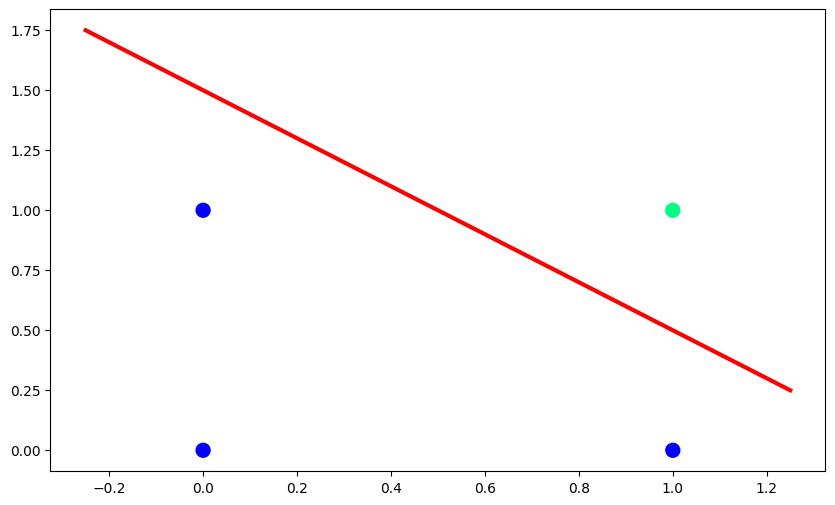

In [10]:
x_input = np.linspace(-0.25,1.25,100)
y_input = m*x_input + c

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
# plt.ylim(-3,2)

# **AND Logic for 3 inputs (Perceptron Loss Function 3D)**

In [11]:
X = np.array([[0,0,0],
              [0,0,1],
              [0,1,0],
              [0,1,1],
              [1,0,0],
              [1,0,1],
              [1,1,0],
              [1,1,1],])
y = np.array([-1,-1,-1,-1,-1,-1,-1,1])

In [12]:
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=X[:, 0],
    y=X[:, 1],
    z=X[:, 2],
    mode='markers',
    marker=dict(
        size=8,
        color=y[:],
        colorscale='bluered'
    ),
    name='Data Points'
))

fig.update_layout(
    scene=dict(
        xaxis_title='X1',
        yaxis_title='X2',
        zaxis_title='X3'
    ),
    width=900,
    height=700
)

fig.show()

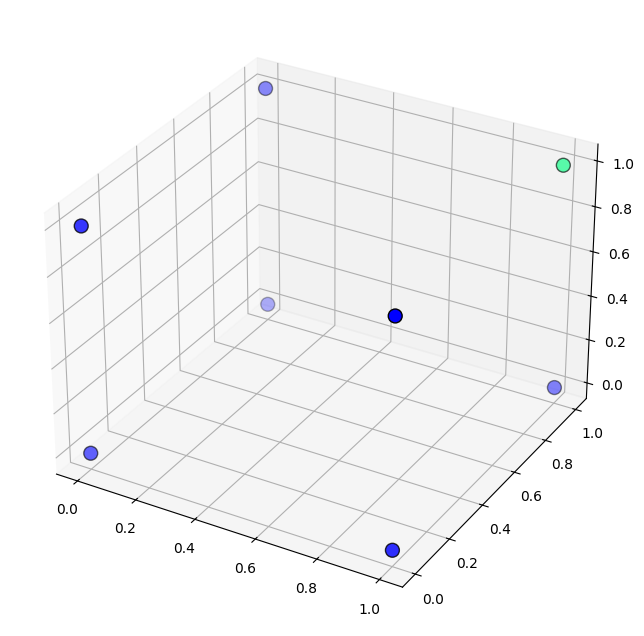

In [13]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the data points
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y[:], cmap='winter', s=100, edgecolors='k')
plt.show()

In [14]:
def perceptron(X,y):

    w1=w2=w3=b=1
    lr = 0.1
    count = 0

    for j in range(1000):

        for i in range(X.shape[0]):

            # check condition
            z = w1*X[i][0] + w2*X[i][1] + w3*X[i][2] + b

            if z*y[i] < 0:
                count = count + 1
                # update rules of gradient decent
                w1 = w1 + lr*y[i]*X[i][0]
                w2 = w2 + lr*y[i]*X[i][1]
                w3 = w3 + lr*y[i]*X[i][2]
                b = b + lr*y[i]

    print(count)
    return w1,w2,w3,b

In [15]:
w1,w2,w3,b = perceptron(X,y)


17


In [16]:
import plotly.graph_objects as go

x_input = np.linspace(-0.25, 1.5, 100)
y_input = np.linspace(-0.25, 1.5, 100)

xx, yy = np.meshgrid(x_input, y_input)

zz = -(w1 * xx + w2 * yy + b) / w3

fig = go.Figure()

fig.add_trace(go.Surface(
    x=xx,
    y=yy,
    z=zz,
    opacity=0.5,
    name='Decision Boundary'
))

fig.add_trace(go.Scatter3d(
    x=X[:, 0],
    y=X[:, 1],
    z=X[:, 2],
    mode='markers',
    marker=dict(
        size=8,
        color=y[:],
        colorscale='bluered'
    ),
    name='Data Points'
))

fig.update_layout(
    scene=dict(
        xaxis_title='X1',
        yaxis_title='X2',
        zaxis_title='X3'
    ),
    width=900,
    height=700
)

fig.show()

# **Perceptron Loss Function on Real World Data (2D)**

In [ ]:
df = pd.read_csv('placement.csv')
df

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


In [ ]:
df['placed'] = df['placed'].replace(0, -1)
display(df.head())

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,-1
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


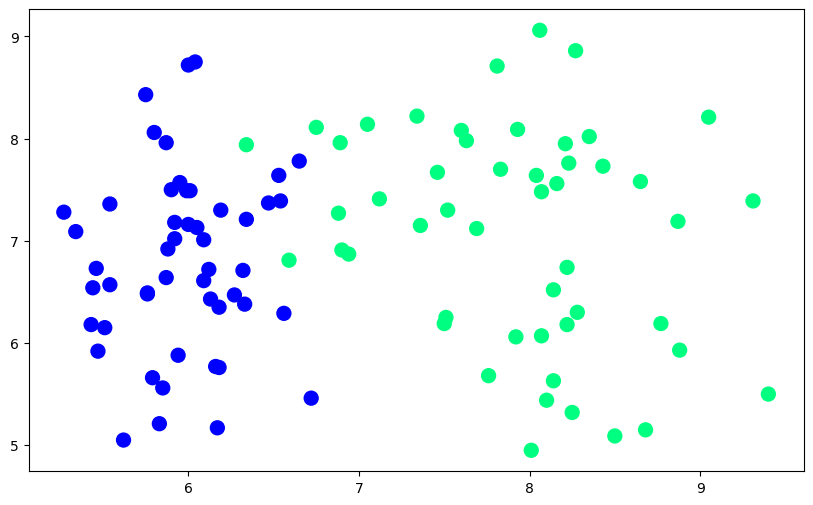

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(df['cgpa'],df['resume_score'],c=df['placed'],cmap='winter',s=100)

In [ ]:
def perceptron(df):

    X = df[['cgpa', 'resume_score']].values
    y = df['placed'].values

    w1=w2=b=1
    lr = 0.1
    count = 0

    for j in range(1000):

        for i in range(X.shape[0]):

            # check condition
            z = w1*X[i][0] + w2*X[i][1] + b

            if z*y[i] < 0:
                count = count + 1

                w1 = w1 + lr*y[i]*X[i][0]
                w2 = w2 + lr*y[i]*X[i][1]
                b = b + lr*y[i]

    print(f"Number of misclassifications/updates: {count}")
    return w1,w2,b

In [ ]:
w1,w2,b = perceptron(df)

Number of misclassifications/updates: 12521


In [ ]:
m = -(w1/w2)
c = -(b/w2)

print(m,c)

-43.98253275111108 310.48034934507916


(4.0, 10.0)

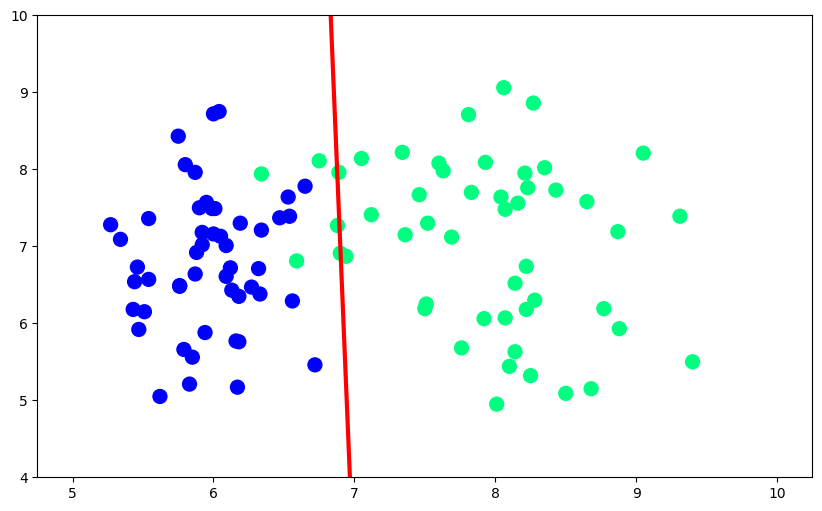

In [ ]:
x_input = np.linspace(5,10,100)
y_input = m*x_input + c

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(df['cgpa'],df['resume_score'],c=df['placed'],cmap='winter',s=100)
plt.ylim(4,10)

# **Perceptron Loss Function on Real World Data (3D)**

In [1]:
from sklearn.datasets import make_classification
import pandas as pd

# Generate a linearly separable synthetic dataset with 3 features and a binary target
# n_informative=3 and n_redundant=0 ensure all features contribute to separation
# n_clusters_per_class=1 ensures clear, single clusters for each class, aiding linear separability
X_separable, y_separable = make_classification(n_samples=100, n_features=3, n_informative=3, n_redundant=0, n_repeated=0, n_classes=2, n_clusters_per_class=1, random_state=42)

# Create a DataFrame
df_separable = pd.DataFrame(X_separable, columns=['input_feature_1', 'input_feature_2', 'input_feature_3'])
df_separable['output'] = y_separable

# Save the DataFrame to a CSV file
csv_file_path_separable = 'linearly_separable_dataset.csv'
df_separable.to_csv(csv_file_path_separable, index=False)

print(f"Linearly separable dataset saved to '{csv_file_path_separable}'")

Linearly separable dataset saved to 'linearly_separable_dataset.csv'


In [2]:
# Display the first few rows of the generated linearly separable dataset
display(df_separable.head())

,input_feature_1,input_feature_2,input_feature_3,output
0,-0.869581,-0.877015,0.442002,0
1,-2.152784,-0.372301,-0.647297,0
2,-2.111619,-0.480863,-0.517866,0
3,1.126601,-2.704236,2.851804,1
4,-1.561107,-0.875682,0.306535,0


In [30]:
# Convert 0s in target column to -1s for perceptron training
df_separable['output'] = df_separable['output'].replace(0, -1)

# Display the first few rows again to confirm the change
display(df_separable.head())

,input_feature_1,input_feature_2,input_feature_3,output
0,-0.869581,-0.877015,0.442002,-1
1,-2.152784,-0.372301,-0.647297,-1
2,-2.111619,-0.480863,-0.517866,-1
3,1.126601,-2.704236,2.851804,1
4,-1.561107,-0.875682,0.306535,-1


In [31]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=df_separable.iloc[:, 0],
    y=df_separable.iloc[:, 1],
    z=df_separable.iloc[:, 2],
    mode='markers',
    marker=dict(
        size=8,
        color=y_separable[:],
        colorscale='bluered'
    ),
    name='Data Points'
))

fig.update_layout(
    scene=dict(
        xaxis_title='X1',
        yaxis_title='X2',
        zaxis_title='X3'
    ),
    width=900,
    height=700
)

fig.show()

In [32]:
def perceptron(df):

    X = df_separable[['input_feature_1', 'input_feature_2', 'input_feature_3' ]].values
    y = df_separable['output'].values

    w1=w2=w3=b=1
    lr = 0.1
    count = 0

    for j in range(1000):

        for i in range(X.shape[0]):

            # check condition
            z = w1*X[i][0] + w2*X[i][1] + w3*X[i][2] + b

            if z*y[i] < 0:
                count = count + 1

                w1 = w1 + lr*y[i]*X[i][0]
                w2 = w2 + lr*y[i]*X[i][1]
                w3 = w3 + lr*y[i]*X[i][2]
                b = b + lr*y[i]

    print(f"Number of misclassifications/updates: {count}")
    return w1,w2,w3,b

In [33]:
w1,w2,w3,b = perceptron(df_separable)

Number of misclassifications/updates: 8812


In [40]:
import plotly.graph_objects as go

x_input = np.linspace(-2, 1.5, 100)
y_input = np.linspace(-3, 1, 100)

xx, yy = np.meshgrid(x_input, y_input)

zz = -(w1 * xx + w2 * yy + b) / w3

fig = go.Figure()

fig.add_trace(go.Surface(
    x=xx,
    y=yy,
    z=zz,
    opacity=0.5,
    name='Decision Boundary'
))

fig.add_trace(go.Scatter3d(
    x=df_separable.iloc[:, 0],
    y=df_separable.iloc[:, 1],
    z=df_separable.iloc[:, 2],
    mode='markers',
    marker=dict(
        size=8,
        color=y_separable[:],
        colorscale='bluered'
    ),
    name='Data Points'
))

fig.update_layout(
    scene=dict(
        xaxis_title='X1',
        yaxis_title='X2',
        zaxis_title='X3'
    ),
    width=900,
    height=700
)

fig.show()